## Bước 1: Business understanding

In [1]:
from dataclasses import dataclass, field
from typing import Dict, List
import pandas as pd

In [2]:
class ProblemDefinition:

  def __init__(
      self,
      problem_id: int,
      title: str,
      business_goal: str,
      target_audience: str,
      ml_task: str,
      evaluation_metrics: List[str],
      input_datasets: List[str],
      core_features: List[str],
      target_variable: str = "None (Unsupervised)",
  ):
    self.problem_id = problem_id
    self.title = title
    self.business_goal = business_goal
    self.target_audience = target_audience
    self.ml_task = ml_task
    self.evaluation_metrics = evaluation_metrics
    self.input_datasets = input_datasets
    self.core_features = core_features
    self.target_variable = target_variable

In [3]:
class BusinessUnderstandingModule:
    """Module định hình mục tiêu kinh doanh và kiểm toán khả thi dữ liệu."""
    
    def __init__(self):
        self.problems: Dict[int, ProblemDefinition] = {}
        self._init_project_scope()

    def _init_project_scope(self):
        # 1. Mục tiêu / Vấn đề 1: Content-Based Similarity
        self.problems[1] = ProblemDefinition(
            problem_id=1,
            title="Đề xuất các công ty tương tự (Content-Based Similarity)",
            business_goal="Gợi ý các công ty có hồ sơ tương đồng để giúp doanh nghiệp tìm đối thủ cạnh tranh/đối tác tiềm năng và ứng viên tìm môi trường phù hợp.",
            target_audience="Doanh nghiệp tuyển dụng & Ứng viên IT",
            ml_task="Unsupervised Learning / Information Retrieval (TF-IDF, Cosine Similarity)",
            evaluation_metrics=["Cosine Similarity Score", "Precision@K", "Domain Expert Evaluation"],
            input_datasets=["Overview_Companies.xlsx"],
            core_features=[
                "Company overview",
                "Company industry",
                "Company Type",
                "Our key skills",
                "Why you'll love working here"])
        
        # 2. Mục tiêu / Vấn đề 2: Classification Recommend
        self.problems[2] = ProblemDefinition(
            problem_id=2,
            title="Phân loại khả năng \"Recommend\" công ty (Recommend or Not)",
            business_goal="Dự đoán khả năng nhân viên/ứng viên giới thiệu công ty (Recommend: Yes/No) dựa trên nội dung review và các điểm đánh giá chi tiết.",
            target_audience="Ứng viên IT tìm việc & Bộ phận HR cải thiện văn hóa doanh nghiệp",
            ml_task="Supervised Learning / Binary Classification",
            evaluation_metrics=["F1-Score", "ROC-AUC", "Precision", "Recall"],
            input_datasets=["Reviews.xlsx", "Overview_Reviews.xlsx"],
            core_features=[
                "Rating",
                "Salary & benefits",
                "Training & learning",
                "Management cares about me",
                "Culture & fun",
                "Office & workspace",
                "Title",
                "What I liked",
                "Suggestions for improvement"],
            target_variable="Recommend? (Yes: 1, No: 0)")

    def print_business_specs(self):
        """In tài liệu đặc tả bài toán nghiệp vụ."""
        print("=" * 80)
        print("BƯỚC 1: BUSINESS UNDERSTANDING - ITVIEC ANALYTICS PROJECT")
        print("=" * 80)
        for pid, p in self.problems.items():
            print(f"\n[VẤN ĐỀ {pid}]: {p.title}")
            print(f" - Mục tiêu nghiệp vụ : {p.business_goal}")
            print(f" - Đối tượng thụ hưởng: {p.target_audience}")
            print(f" - Bản chất kỹ thuật  : {p.ml_task}")
            print(f" - Biến mục tiêu      : {p.target_variable}")
            print(f" - Bộ dữ liệu sử dụng : {', '.join(p.input_datasets)}")
            print(f" - Thước đo đánh giá  : {', '.join(p.evaluation_metrics)}")

    def audit_datasets(self) -> Dict[str, pd.DataFrame]:
        """Kiểm toán dữ liệu từ đúng 3 file Excel ban đầu."""
        print("\n" + "=" * 80)
        print("KIỂM TOÁN TÍNH KHẢ THI CỦA 3 TỆP DỮ LIỆU BAN ĐẦU")
        print("=" * 80)
        
        dfs = {
            "companies": pd.read_excel("Overview_Companies.xlsx"),
            "overview_reviews": pd.read_excel("Overview_Reviews.xlsx"),
            "reviews": pd.read_excel("Reviews.xlsx")}
        
        print(f"✓ Overview_Companies : {dfs['companies'].shape[0]} công ty, {dfs['companies'].shape[1]} thuộc tính")
        print(f"✓ Overview_Reviews   : {dfs['overview_reviews'].shape[0]} dòng tổng hợp, {dfs['overview_reviews'].shape[1]} chỉ số")
        print(f"✓ Reviews            : {dfs['reviews'].shape[0]} lượt đánh giá chi tiết, {dfs['reviews'].shape[1]} trường thông tin")
        
        # 1. Khảo sát Vấn đề 1
        comp_df = dfs["companies"]
        text_completeness = (comp_df["Company overview"].notnull().sum() / len(comp_df)) * 100
        print(f"\n[Vấn đề 1] Độ phủ cột 'Company overview': {text_completeness:.1f}%")
        print(f"           Số công ty có kỹ năng chính ('Our key skills'): {comp_df['Our key skills'].notnull().sum()}/{len(comp_df)}")
        print(f"           => Đủ điều kiện xây dựng Content-Based Recommendation.")
        
        # 2. Khảo sát Vấn đề 2
        rev_df = dfs["reviews"]
        target_counts = rev_df["Recommend?"].value_counts(dropna=False)
        target_pct = rev_df["Recommend?"].value_counts(normalize=True) * 100
        
        print(f"\n[Vấn đề 2] Phân phối biến mục tiêu 'Recommend?':")
        for label, count in target_counts.items():
            print(f"   - {label}: {count} quan sát ({target_pct[label]:.2f}%)")
            
        print("\n=> Đánh giá kỹ thuật (Data Science Risk & Plan):")
        print(f"   Tập nhãn bị mất cân bằng lớp (Yes chiếm {target_pct['Yes']:.1f}% so với No {target_pct['No']:.1f}%).")
        print("   Khi xây dựng mô hình phân loại, cần áp dụng SMOTE/class_weight='balanced' và đánh giá bằng Macro F1 / ROC-AUC.")
        
        return dfs

In [4]:
if __name__ == "__main__":
    bu = BusinessUnderstandingModule()
    bu.print_business_specs()
    datasets = bu.audit_datasets()

BƯỚC 1: BUSINESS UNDERSTANDING - ITVIEC ANALYTICS PROJECT

[VẤN ĐỀ 1]: Đề xuất các công ty tương tự (Content-Based Similarity)
 - Mục tiêu nghiệp vụ : Gợi ý các công ty có hồ sơ tương đồng để giúp doanh nghiệp tìm đối thủ cạnh tranh/đối tác tiềm năng và ứng viên tìm môi trường phù hợp.
 - Đối tượng thụ hưởng: Doanh nghiệp tuyển dụng & Ứng viên IT
 - Bản chất kỹ thuật  : Unsupervised Learning / Information Retrieval (TF-IDF, Cosine Similarity)
 - Biến mục tiêu      : None (Unsupervised)
 - Bộ dữ liệu sử dụng : Overview_Companies.xlsx
 - Thước đo đánh giá  : Cosine Similarity Score, Precision@K, Domain Expert Evaluation

[VẤN ĐỀ 2]: Phân loại khả năng "Recommend" công ty (Recommend or Not)
 - Mục tiêu nghiệp vụ : Dự đoán khả năng nhân viên/ứng viên giới thiệu công ty (Recommend: Yes/No) dựa trên nội dung review và các điểm đánh giá chi tiết.
 - Đối tượng thụ hưởng: Ứng viên IT tìm việc & Bộ phận HR cải thiện văn hóa doanh nghiệp
 - Bản chất kỹ thuật  : Supervised Learning / Binary Classi

## Bước 2: Data understanding

In [5]:
from typing import Dict, Tuple
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [6]:
class Step2DataUnderstanding:
    def __init__(
        self,
        comp_path: str = "Overview_Companies.xlsx",
        rev_path: str = "Reviews.xlsx",
        rev_ov_path: str = "Overview_Reviews.xlsx"
    ):
        self.comp_path = comp_path
        self.rev_path = rev_path
        self.rev_ov_path = rev_ov_path
        
        self.df_comp = None
        self.df_rev = None
        self.df_rev_ov = None

    def load_data(self):
        """1. Nạp 3 tập dữ liệu phục vụ 2 bài toán."""
        print("=" * 80)
        print("BƯỚC 2: DATA UNDERSTANDING & ALGORITHM STRUCTURING")
        print("=" * 80)
        self.df_comp = pd.read_excel(self.comp_path)
        self.df_rev = pd.read_excel(self.rev_path)
        self.df_rev_ov = pd.read_excel(self.rev_ov_path)
        
        print(f"✓ Dataset 1 (Companies)        : {self.df_comp.shape[0]} công ty x {self.df_comp.shape[1]} cột")
        print(f"✓ Dataset 2 (Reviews)          : {self.df_rev.shape[0]} lượt đánh giá x {self.df_rev.shape[1]} cột")
        print(f"✓ Dataset 3 (Overview Reviews) : {self.df_rev_ov.shape[0]} dòng x {self.df_rev_ov.shape[1]} cột")

    # --------------------------------------------------------------------------
    # NHÁNH 1: CONTENT-BASED FILTERING (GENSIM & SCIKIT-LEARN COSINE SIMILARITY)
    # --------------------------------------------------------------------------
    def inspect_content_based_features(self) -> pd.DataFrame:
        """
        Khảo sát các trường văn bản cho bài toán Content-Based:
        Gensim / Scikit-learn Cosine Similarity.
        """
        print("\n" + "-" * 80)
        print("[NHÁNH 1] KHẢO SÁT ĐẶC TRƯNG CHO CONTENT-BASED FILTERING")
        print("-" * 80)
        
        # Lấy các trường văn bản cốt lõi
        text_cols = ['Company overview', 'Our key skills', "Why you'll love working here", 'Company industry', 'Company Type']
        print("Các trường thông tin được chọn để biểu diễn ngữ nghĩa:")
        for col in text_cols:
            non_null = self.df_comp[col].notnull().sum()
            print(f" - {col:<30}: {non_null}/{len(self.df_comp)} ({non_null/len(self.df_comp)*100:.1f}%)")
            
        # Thống kê độ dài văn bản (word count) của Company overview
        overview_lens = self.df_comp['Company overview'].fillna('').apply(lambda x: len(str(x).split()))
        print(f"\nThống kê số từ trường 'Company overview':")
        print(f" - Trung bình: {overview_lens.mean():.1f} từ | Trung vị: {overview_lens.median():.0f} từ")
        print(f" - Ngắn nhất : {overview_lens.min()} từ   | Dài nhất : {overview_lens.max()} từ")
        
        # Trích xuất dataframe phục vụ bài toán 1
        comp_content_df = self.df_comp[['id', 'Company Name'] + text_cols].copy()
        return comp_content_df

    # --------------------------------------------------------------------------
    # NHÁNH 2: CLASSIFICATION (LOGISTIC REGRESSION, TREE MODELS, SVM...)
    # --------------------------------------------------------------------------
    def inspect_classification_features(self) -> pd.DataFrame:
        """
        Khảo sát phân phối nhãn và tương quan các biến số cho Classification:
        Logistic Regression, Tree Models (RF/XGBoost), SVM.
        """
        print("\n" + "-" * 80)
        print("[NHÁNH 2] KHẢO SÁT ĐẶC TRƯNG CHO BÀI TOÁN PHÂN LOẠI (CLASSIFICATION)")
        print("-" * 80)
        
        # 1. Biến mục tiêu Recommend?
        target_counts = self.df_rev['Recommend?'].value_counts()
        target_ratio = self.df_rev['Recommend?'].value_counts(normalize=True) * 100
        print(f"Phân phối nhãn mục tiêu 'Recommend?':")
        print(f" - Yes : {target_counts['Yes']} ({target_ratio['Yes']:.2f}%)")
        print(f" - No  : {target_counts['No']} ({target_ratio['No']:.2f}%)")
        
        # 2. Đánh giá tương quan giữa các điểm số Rating và Recommend?
        rev_prep = self.df_rev.copy()
        rev_prep['target_num'] = rev_prep['Recommend?'].map({'Yes': 1, 'No': 0})
        
        rating_cols = [
            'Rating', 'Salary & benefits', 'Training & learning',
            'Management cares about me', 'Culture & fun', 'Office & workspace']
        
        corr_series = rev_prep[rating_cols + ['target_num']].corr()['target_num'].drop('target_num').sort_values(ascending=False)
        print("\nHệ số tương quan tuyến tính (Pearson Correlation) với nhãn Recommend:")
        for col, val in corr_series.items():
            print(f" - {col:<30}: {val:.4f}")
            
        print("\n=> Nhận xét thuật toán:")
        print(" • 'Rating' tổng quan và 'Management cares about me' có tương quan mạnh nhất đến quyết định Recommend.")
        print(" • Thuật toán Logistic Regression & Linear SVM có thể học tốt từ các đặc trưng số này.")
        print(" • Nhóm Tree Models (Random Forest, XGBoost) sẽ hữu hiệu khi kết hợp thêm đặc trưng phi tuyến từ NLP (Title, What I liked).")

        return rev_prep

In [7]:
# Chạy kiểm thử Bước 2
if __name__ == "__main__":
    step2 = Step2DataUnderstanding()
    step2.load_data()
    comp_features = step2.inspect_content_based_features()
    rev_features = step2.inspect_classification_features()

BƯỚC 2: DATA UNDERSTANDING & ALGORITHM STRUCTURING
✓ Dataset 1 (Companies)        : 478 công ty x 13 cột
✓ Dataset 2 (Reviews)          : 8417 lượt đánh giá x 13 cột
✓ Dataset 3 (Overview Reviews) : 478 dòng x 10 cột

--------------------------------------------------------------------------------
[NHÁNH 1] KHẢO SÁT ĐẶC TRƯNG CHO CONTENT-BASED FILTERING
--------------------------------------------------------------------------------
Các trường thông tin được chọn để biểu diễn ngữ nghĩa:
 - Company overview              : 478/478 (100.0%)
 - Our key skills                : 321/478 (67.2%)
 - Why you'll love working here  : 379/478 (79.3%)
 - Company industry              : 463/478 (96.9%)
 - Company Type                  : 478/478 (100.0%)

Thống kê số từ trường 'Company overview':
 - Trung bình: 142.4 từ | Trung vị: 140 từ
 - Ngắn nhất : 2 từ   | Dài nhất : 466 từ

--------------------------------------------------------------------------------
[NHÁNH 2] KHẢO SÁT ĐẶC TRƯNG CHO BÀI TOÁN

## Bước 3: Data preparation

In [8]:
import re
import string
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import gensim
from gensim import corpora, models, similarities

In [9]:
# Bộ stop words tùy chỉnh theo mẫu demo
DEFAULT_STOP_WORDS = set(ENGLISH_STOP_WORDS).union({
    "a", "an", "the", "in", "on", "at", "to", "from", "by", "of", "with",
    "and", "but", "or", "for", "nor", "so", "yet", "i", "you", "he", "she",
    "it", "we", "they", "me", "him", "her", "us", "them", "we’re", "be",
    "have", "do", "does", "did", "was", "were", "will", "would", "shall",
    "should", "may", "might", "can", "could", "must", "that", "this",
    "which", "what", "their", "these", "those", "https", "www", "com", "vn"})

In [10]:
# ==============================================================================
# 1. TIỀN XỬ LÝ DỮ LIỆU TEXT (TEXT PREPROCESSING)
# ==============================================================================

def clean_text(text: object, stop_words: Optional[set] = None) -> str:
    """Chuẩn hóa chuỗi văn bản: chữ thường, bỏ ký tự đặc biệt, URL, khoảng trắng thừa."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    # Loại bỏ đường link URL
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    # Loại bỏ số và ký tự đặc biệt, chỉ giữ lại chữ cái và khoảng trắng
    text = re.sub(r"[^a-zA-Z\sàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ]", " ", text)
    words = text.split()
    
    # Loại bỏ stop words
    stops = stop_words or DEFAULT_STOP_WORDS
    tokens = [w for w in words if w not in stops and len(w) > 1]
    return " ".join(tokens)


def tokenize_corpus(text_series: pd.Series) -> List[List[str]]:
    """Chuyển Series văn bản thành danh sách token phục vụ Gensim."""
    return [str(doc).split() for doc in text_series]

In [11]:
# ==============================================================================
# 2. XỬ LÝ CHO BÀI TOÁN 1: CONTENT-BASED SIMILARITY (Overview_Companies)
# ==============================================================================

def prepare_companies_data(comp_file: str = "Overview_Companies.xlsx") -> pd.DataFrame:
    """
    Chuẩn bị dữ liệu công ty:
    - Data Consolidation: Kết hợp overview, key skills, industry, company type thành 1 cột mô tả tổng hợp.
    - Data Cleaning: Xử lý missing values.
    - Data Transformation: Làm sạch text.
    """
    df = pd.read_excel(comp_file)
    
    # Xử lý missing values bằng chuỗi rỗng
    df["Company overview"] = df["Company overview"].fillna("")
    df["Our key skills"] = df["Our key skills"].fillna("")
    df["Why you'll love working here"] = df["Why you'll love working here"].fillna("")
    df["Company industry"] = df["Company industry"].fillna("")
    df["Company Type"] = df["Company Type"].fillna("")
    
    # Hợp nhất nội dung mô tả (Feature Construction / Consolidation)
    df["combined_profile"] = (
        df["Company overview"] + " " +
        df["Our key skills"] + " " +
        df["Why you'll love working here"] + " " +
        df["Company industry"] + " " +
        df["Company Type"])
    
    # Tiền xử lý text cho scikit-learn
    df["clean_profile"] = df["combined_profile"].apply(lambda x: clean_text(x, DEFAULT_STOP_WORDS))
    
    # Tokenization cho Gensim
    df["tokens"] = tokenize_corpus(df["clean_profile"])
    
    print(f"✓ Hoàn tất chuẩn bị dữ liệu Công ty: {df.shape[0]} công ty.")
    return df

In [12]:
# ==============================================================================
# 3. XỬ LÝ CHO BÀI TOÁN 2: CLASSIFICATION (Reviews)
# ==============================================================================

def prepare_reviews_data(
    rev_file: str = "Reviews.xlsx",
    test_size: float = 0.2,
    random_state: int = 42
) -> Dict[str, object]:
    """
    Chuẩn bị dữ liệu Reviews cho bài toán phân loại:
    - Numeric: Chuẩn hóa 6 chỉ số Rating (1-5 sao) bằng StandardScaler.
    - Target: Chuyển đổi 'Recommend?' (Yes -> 1, No -> 0).
    - Text: Làm sạch Title, What I liked, Suggestions.
    - Stratified Train/Test split để duy trì tỷ lệ mất cân bằng lớp.
    """
    df = pd.read_excel(rev_file)
    
    # 1. Data Cleaning
    df["Title"] = df["Title"].fillna("")
    df["What I liked"] = df["What I liked"].fillna("")
    df["Suggestions for improvement"] = df["Suggestions for improvement"].fillna("")
    
    # 2. Xử lý Text của review
    df["review_text_combined"] = df["Title"] + " " + df["What I liked"] + " " + df["Suggestions for improvement"]
    df["clean_review_text"] = df["review_text_combined"].apply(lambda x: clean_text(x, DEFAULT_STOP_WORDS))
    
    # 3. Xử lý Target (Encoding)
    df["target"] = df["Recommend?"].map({"Yes": 1, "No": 0}).astype(int)
    
    # 4. Xử lý Numeric Features (6 thang điểm rating)
    numeric_features = [
        "Rating",
        "Salary & benefits",
        "Training & learning",
        "Management cares about me",
        "Culture & fun",
        "Office & workspace"]
    
    # 5. Phân chia Train/Test theo Stratified
    X_num = df[numeric_features]
    X_text = df["clean_review_text"]
    y = df["target"]
    
    X_num_train, X_num_test, X_text_train, X_text_test, y_train, y_test = train_test_split(
        X_num, X_text, y, test_size=test_size, random_state=random_state, stratify=y)
    
    # 6. Chuẩn hóa Numeric (StandardScaler fit trên train, transform trên test)
    scaler = StandardScaler()
    X_num_train_scaled = scaler.fit_transform(X_num_train)
    X_num_test_scaled = scaler.transform(X_num_test)
    
    print(f"✓ Hoàn tất chuẩn bị dữ liệu Reviews: {df.shape[0]} mẫu.")
    print(f"   - Tập Train: {X_num_train.shape[0]} mẫu (Tỷ lệ Yes: {y_train.mean()*100:.2f}%)")
    print(f"   - Tập Test : {X_num_test.shape[0]} mẫu (Tỷ lệ Yes: {y_test.mean()*100:.2f}%)")
    
    return {
        "df_reviews": df,
        "numeric_features": numeric_features,
        "scaler": scaler,
        "X_num_train_scaled": X_num_train_scaled,
        "X_num_test_scaled": X_num_test_scaled,
        "X_text_train": X_text_train,
        "X_text_test": X_text_test,
        "y_train": y_train,
        "y_test": y_test}

In [13]:
# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    print("=" * 80)
    print("BƯỚC 3: DATA PREPARATION (TIỀN XỬ LÝ DỮ LIỆU TEXT & NUMERIC)")
    print("=" * 80)
    
    # Thực hiện tiền xử lý cho bài toán 1
    companies_prepared = prepare_companies_data("Overview_Companies.xlsx")
    print("\n[Mẫu hồ sơ công ty sau tiền xử lý text]:")
    print(companies_prepared[["Company Name", "clean_profile"]].head(2))
    
    print("\n" + "-" * 80 + "\n")
    
    # Thực hiện tiền xử lý cho bài toán 2
    reviews_prepared = prepare_reviews_data("Reviews.xlsx")
    print("\n[Mẫu nhãn mục tiêu và đặc trưng số sau khi Scale]:")
    print("y_train sample:", reviews_prepared["y_train"].head().tolist())
    print("X_num_train_scaled shape:", reviews_prepared["X_num_train_scaled"].shape)

BƯỚC 3: DATA PREPARATION (TIỀN XỬ LÝ DỮ LIỆU TEXT & NUMERIC)
✓ Hoàn tất chuẩn bị dữ liệu Công ty: 478 công ty.

[Mẫu hồ sơ công ty sau tiền xử lý text]:
         Company Name                                      clean_profile
0  1BITLAB Technology  bitlab technology công ty cổ phần công nghệ bi...
1               1test  test innovative educational technology company...

--------------------------------------------------------------------------------

✓ Hoàn tất chuẩn bị dữ liệu Reviews: 8417 mẫu.
   - Tập Train: 6733 mẫu (Tỷ lệ Yes: 87.73%)
   - Tập Test : 1684 mẫu (Tỷ lệ Yes: 87.77%)

[Mẫu nhãn mục tiêu và đặc trưng số sau khi Scale]:
y_train sample: [1, 1, 1, 1, 1]
X_num_train_scaled shape: (6733, 6)


## Bước 4, 5: Modeling, Evaluation, Analyze and Report

#### Yêu cầu 1:

In [14]:
import math
import re
from typing import Dict, List, Optional, Tuple
from gensim import corpora, models, similarities
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [15]:
# Bổ sung bộ stop words cho lĩnh vực IT và tuyển dụng
CUSTOM_STOP_WORDS = set(ENGLISH_STOP_WORDS).union(
    {
        "a",
        "an",
        "the",
        "in",
        "on",
        "at",
        "to",
        "from",
        "by",
        "of",
        "with",
        "and",
        "but",
        "or",
        "for",
        "nor",
        "so",
        "yet",
        "i",
        "you",
        "he",
        "she",
        "it",
        "we",
        "they",
        "me",
        "him",
        "her",
        "us",
        "them",
        "we’re",
        "be",
        "have",
        "do",
        "does",
        "did",
        "was",
        "were",
        "will",
        "would",
        "shall",
        "should",
        "may",
        "might",
        "can",
        "could",
        "must",
        "that",
        "this",
        "which",
        "what",
        "their",
        "these",
        "those",
        "https",
        "www",
        "com",
        "vn",
    }
)

In [16]:
def clean_text(text: object) -> str:
  """Tiền xử lý và làm sạch chuỗi văn bản."""
  if pd.isna(text):
    return ""
  text = str(text).lower()
  text = re.sub(r"https?://\S+|www\.\S+", " ", text)
  text = re.sub(
      r"[^a-zA-Z\sàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ]",
      " ",
      text,
  )
  tokens = [
      w for w in text.split() if w not in CUSTOM_STOP_WORDS and len(w) > 1
  ]
  return " ".join(tokens)

In [17]:
def load_and_preprocess_companies(
    file_path: str = "Overview_Companies.xlsx",
) -> pd.DataFrame:
  """Đọc file Excel và tiền xử lý 5 trường văn bản chính."""
  df = pd.read_excel(file_path)

  df["Company overview"] = df["Company overview"].fillna("")
  df["Our key skills"] = df["Our key skills"].fillna("")
  df["Why you'll love working here"] = df[
      "Why you'll love working here"
  ].fillna("")
  df["Company industry"] = df["Company industry"].fillna("")
  df["Company Type"] = df["Company Type"].fillna("")

  df["full_content"] = (
      df["Company overview"]
      + " "
      + df["Our key skills"]
      + " "
      + df["Why you'll love working here"]
      + " "
      + df["Company industry"]
      + " "
      + df["Company Type"]
  )

  df["clean_content"] = df["full_content"].apply(clean_text)
  df["tokens"] = df["clean_content"].apply(lambda x: x.split())
  print(f"✓ Đã tiền xử lý thành công {len(df)} công ty.")
  return df

In [18]:
# ==============================================================================
# PIPELINE 1: SCIKIT-LEARN (TFIDFVECTORIZER + COSINE SIMILARITY)
# ==============================================================================
class SklearnRecommender:

  def __init__(self, min_df: float = 1):
    self.vectorizer = TfidfVectorizer(min_df=min_df)
    self.tfidf_matrix = None
    self.similarity_matrix = None
    self.df = None

  def fit(self, df: pd.DataFrame):
    self.df = df
    self.tfidf_matrix = self.vectorizer.fit_transform(df["clean_content"])
    self.similarity_matrix = cosine_similarity(
        self.tfidf_matrix, self.tfidf_matrix
    )
    print(
        f"[Scikit-learn] Đã tạo ma trận TF-IDF: {self.tfidf_matrix.shape[0]} doc"
        f" x {self.tfidf_matrix.shape[1]} terms."
    )

  def recommend(self, item_index: int, top_k: int = 5) -> pd.DataFrame:
    scores = self.similarity_matrix[item_index].copy()
    scores[item_index] = -1
    ranked_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for rank, idx in enumerate(ranked_indices, 1):
      results.append({
          "Rank": rank,
          "Index": idx,
          "Company Name": self.df.iloc[idx]["Company Name"],
          "Similarity (Sklearn)": round(float(scores[idx]), 4),
      })
    return pd.DataFrame(results)

In [19]:
# ==============================================================================
# PIPELINE 2: GENSIM (DICTIONARY + TFIDFMODEL + SPARSE MATRIX SIMILARITY)
# ==============================================================================
class GensimRecommender:

  def __init__(self):
    self.dictionary = None
    self.tfidf_model = None
    self.similarity_index = None
    self.df = None

  def fit(self, df: pd.DataFrame):
    self.df = df
    documents = df["tokens"].tolist()

    self.dictionary = corpora.Dictionary(documents)
    corpus = [self.dictionary.doc2bow(doc) for doc in documents]

    self.tfidf_model = models.TfidfModel(corpus)
    self.similarity_index = similarities.SparseMatrixSimilarity(
        self.tfidf_model[corpus], num_features=len(self.dictionary)
    )
    print(
        f"[Gensim] Đã lập chỉ mục SparseMatrixSimilarity với"
        f" {len(self.dictionary)} features."
    )

  def recommend(self, item_index: int, top_k: int = 5) -> pd.DataFrame:
    doc_bow = self.dictionary.doc2bow(self.df.iloc[item_index]["tokens"])
    doc_tfidf = self.tfidf_model[doc_bow]

    sim_scores = np.array(self.similarity_index[doc_tfidf])
    sim_scores[item_index] = -1

    ranked_indices = np.argsort(sim_scores)[::-1][:top_k]
    results = []
    for rank, idx in enumerate(ranked_indices, 1):
      results.append({
          "Rank": rank,
          "Index": idx,
          "Company Name": self.df.iloc[idx]["Company Name"],
          "Similarity (Gensim)": round(float(sim_scores[idx]), 4),
      })
    return pd.DataFrame(results)

In [20]:
# ==============================================================================
# 4. THUẬT TOÁN ĐỀ XUẤT MỚI: OKAPI BM25 RANKING
# ==============================================================================
class BM25Recommender:
  """Thuật toán Okapi BM25 - tiêu chuẩn công nghiệp trong Information Retrieval hiện đại.

  Khắc phục nhược điểm của TF-IDF nhờ cơ chế bão hòa tần số từ (Term Saturation)
  và phạt độ dài tài liệu linh hoạt (Document Length Normalization).
  """

  def __init__(self, k1: float = 1.5, b: float = 0.75):
    self.k1 = k1
    self.b = b
    self.corpus = []
    self.doc_len = []
    self.avg_doc_len = 0.0
    self.df_dict = {}
    self.idf = {}
    self.df = None

  def fit(self, df: pd.DataFrame):
    self.df = df
    self.corpus = df["tokens"].tolist()
    self.doc_len = [len(doc) for doc in self.corpus]
    self.avg_doc_len = sum(self.doc_len) / len(self.doc_len)
    num_docs = len(self.corpus)

    # Đếm document frequency
    for doc in self.corpus:
      unique_words = set(doc)
      for word in unique_words:
        self.df_dict[word] = self.df_dict.get(word, 0) + 1

    # Tính IDF theo chuẩn BM25
    for word, freq in self.df_dict.items():
      self.idf[word] = math.log((num_docs - freq + 0.5) / (freq + 0.5) + 1.0)

    print(
        f"[BM25] Đã huấn luyện xong BM25 trên {num_docs} tài liệu (Avg length:"
        f" {self.avg_doc_len:.1f} từ).")

  def recommend(self, item_index: int, top_k: int = 5) -> pd.DataFrame:
    query_tokens = self.corpus[item_index]
    scores = np.zeros(len(self.corpus))

    for i, doc in enumerate(self.corpus):
      if i == item_index:
        scores[i] = -1
        continue

      doc_term_freq = {}
      for t in doc:
        doc_term_freq[t] = doc_term_freq.get(t, 0) + 1

      score = 0.0
      doc_l = self.doc_len[i]
      for token in query_tokens:
        if token in doc_term_freq:
          tf = doc_term_freq[token]
          idf = self.idf.get(token, 0.0)
          # Công thức Okapi BM25
          numerator = tf * (self.k1 + 1)
          denominator = tf + self.k1 * (
              1 - self.b + self.b * (doc_l / self.avg_doc_len)
          )
          score += idf * (numerator / denominator)
      scores[i] = score

    ranked_indices = np.argsort(scores)[::-1][:top_k]
    results = []
    for rank, idx in enumerate(ranked_indices, 1):
      results.append({
          "Rank": rank,
          "Index": idx,
          "Company Name": self.df.iloc[idx]["Company Name"],
          "BM25 Score": round(float(scores[idx]), 4),
      })
    return pd.DataFrame(results)

In [21]:
# ==============================================================================
# 5. SO SÁNH VÀ ĐÁNH GIÁ KẾT QUẢ GIỮA CÁC PHƯƠNG PHÁP
# ==============================================================================
def compare_recommenders(
    target_idx: int,
    df_comp: pd.DataFrame,
    sk_rec: 'SklearnRecommender',
    gen_rec: 'GensimRecommender',
    bm25_rec: 'BM25Recommender',
    top_k: int = 5,
):
  target_name = df_comp.iloc[target_idx]["Company Name"]
  print("=" * 85)
  print(f"SO SÁNH KẾT QUẢ GỢI Ý CHO CÔNG TY: [{target_idx}] {target_name.upper()}")
  print("=" * 85)

  df_sk = sk_rec.recommend(target_idx, top_k=top_k)
  df_gen = gen_rec.recommend(target_idx, top_k=top_k)
  df_bm25 = bm25_rec.recommend(target_idx, top_k=top_k)

  # Hợp nhất bảng so sánh
  comparison = pd.DataFrame({
      "Hạng": [f"Top {i}" for i in range(1, top_k + 1)],
      "Scikit-learn (Cosine)": [
          f"{row['Company Name']} ({row['Similarity (Sklearn)']})"
          for _, row in df_sk.iterrows()
      ],
      "Gensim (Sparse Matrix)": [
          f"{row['Company Name']} ({row['Similarity (Gensim)']})"
          for _, row in df_gen.iterrows()
      ],
      "Đề xuất mới: BM25": [
          f"{row['Company Name']} (BM25: {row['BM25 Score']})"
          for _, row in df_bm25.iterrows()
      ],
  })

  display(comparison)
  return comparison

In [22]:
if __name__ == "__main__":
  # 1. Nạp và tiền xử lý
  df_companies = load_and_preprocess_companies("Overview_Companies.xlsx")

  # 2. Khởi tạo và huấn luyện 3 mô hình
  sk_model = SklearnRecommender(min_df=1)
  sk_model.fit(df_companies)

  gensim_model = GensimRecommender()
  gensim_model.fit(df_companies)

  bm25_model = BM25Recommender(k1=1.5, b=0.75)
  bm25_model.fit(df_companies)

  # 3. So sánh trên 2 ca kiểm nghiệm tiêu biểu
  # Case 1: Accenture (ID 4) - Doanh nghiệp Consulting / Cloud toàn cầu
  compare_recommenders(4, df_companies, sk_model, gensim_model, bm25_model)

  print("\n")
  # Case 2: Ahamove (ID 6) - Nền tảng On-demand Logistics / E-commerce
  compare_recommenders(6, df_companies, sk_model, gensim_model, bm25_model)

✓ Đã tiền xử lý thành công 478 công ty.
[Scikit-learn] Đã tạo ma trận TF-IDF: 478 doc x 7312 terms.
[Gensim] Đã lập chỉ mục SparseMatrixSimilarity với 7312 features.
[BM25] Đã huấn luyện xong BM25 trên 478 tài liệu (Avg length: 162.2 từ).
SO SÁNH KẾT QUẢ GỢI Ý CHO CÔNG TY: [4] ACCENTURE


,Hạng,Scikit-learn (Cosine),Gensim (Sparse Matrix),Đề xuất mới: BM25
0,Top 1,MEGAZONE (0.212),MEGAZONE (0.1431),Capgemini Vietnam (BM25: 110.1785)
1,Top 2,NashTech (0.1715),NashTech (0.1091),SkyLab (BM25: 106.8189)
2,Top 3,Capgemini Vietnam (0.1626),Capgemini Vietnam (0.1074),Collaboration Betters The World (CBTW) (BM25: ...
3,Top 4,HONGTHAI Technical (0.1552),Collaboration Betters The World (CBTW) (0.1039),NashTech (BM25: 104.1386)
4,Top 5,SkyLab (0.1546),Collaboration Betters The World - B.O.T (0.0975),MEGAZONE (BM25: 102.2325)




SO SÁNH KẾT QUẢ GỢI Ý CHO CÔNG TY: [6] AHAMOVE


,Hạng,Scikit-learn (Cosine),Gensim (Sparse Matrix),Đề xuất mới: BM25
0,Top 1,CESA Vietnam (part of CEVA Logistic) (0.1171),Reclub Vietnam (0.0968),SoftNET Network Co Ltd. (BM25: 58.9574)
1,Top 2,Reclub Vietnam (0.1114),CESA Vietnam (part of CEVA Logistic) (0.0878),LG CNS Việt Nam (BM25: 56.7104)
2,Top 3,Deliveree On-Demand Logistics (0.1029),Deliveree On-Demand Logistics (0.0801),Zen8Labs (BM25: 52.3132)
3,Top 4,GHN (0.0999),GHN (0.0745),CESA Vietnam (part of CEVA Logistic) (BM25: 52...
4,Top 5,HARAVAN (0.0947),SoftNET Network Co Ltd. (0.0694),Restaff – House Of Norway (BM25: 48.0888)


#### Yêu cầu 2:

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix, roc_curve
from sklearn.svm import SVC



In [32]:
# 1. Lấy dữ liệu train/test đã được chuẩn hóa từ Bước 3
X_train = reviews_prepared["X_num_train_scaled"]
y_train = reviews_prepared["y_train"].values
X_test = reviews_prepared["X_num_test_scaled"]
y_test = reviews_prepared["y_test"].values

print("=" * 80)
print("KHẢO SÁT & XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU (CLASS IMBALANCE)")
print("=" * 80)
unique, counts = np.unique(y_train, return_counts=True)
print(f"Phân phối nhãn Train ban đầu: No (0) = {counts[0]}, Yes (1) = {counts[1]}")
print(f"-> Tỷ lệ thiểu số (No): {counts[0] / len(y_train) * 100:.2f}%\n")

KHẢO SÁT & XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU (CLASS IMBALANCE)
Phân phối nhãn Train ban đầu: No (0) = 826, Yes (1) = 5907
-> Tỷ lệ thiểu số (No): 12.27%



In [33]:
# 2. Phương pháp 1: SMOTE (Synthetic Minority Over-sampling Technique)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [34]:
# 3. Phương pháp 2: SMOTE kết hợp Tomek Links (Oversampling + Làm sạch biên)
smote_tomek = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smote_tomek.fit_resample(X_train, y_train)

In [35]:
# 4. Thống kê so sánh các bộ dữ liệu sau khi cân bằng
resampling_summary = pd.DataFrame({
    "Phương pháp": [
        "Gốc (Imbalanced)",
        "SMOTE",
        "SMOTE + Tomek Links",],
    "Tổng số mẫu": [
        len(y_train),
        len(y_train_smote),
        len(y_train_smt),],
    "Số mẫu Nhãn 0 (No)": [
        np.sum(y_train == 0),
        np.sum(y_train_smote == 0),
        np.sum(y_train_smt == 0),],
    "Số mẫu Nhãn 1 (Yes)": [
        np.sum(y_train == 1),
        np.sum(y_train_smote == 1),
        np.sum(y_train_smt == 1),],
})

In [36]:
print(resampling_summary.to_string(index=False))
print("-" * 80)
print(
    "✓ Khuyến nghị: Sử dụng tập `X_train_smt, y_train_smt` (SMOTETomek) hoặc"
    " `X_train_smote, y_train_smote` để huấn luyện 4 mô hình Sklearn & so sánh.")

        Phương pháp  Tổng số mẫu  Số mẫu Nhãn 0 (No)  Số mẫu Nhãn 1 (Yes)
   Gốc (Imbalanced)         6733                 826                 5907
              SMOTE        11814                5907                 5907
SMOTE + Tomek Links        11814                5907                 5907
--------------------------------------------------------------------------------
✓ Khuyến nghị: Sử dụng tập `X_train_smt, y_train_smt` (SMOTETomek) hoặc `X_train_smote, y_train_smote` để huấn luyện 4 mô hình Sklearn & so sánh.


In [38]:
# 1. Định nghĩa danh sách 4 thuật toán Scikit-learn
models_sklearn = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=150, random_state=42),
    "Support Vector Machine (SVC)": SVC(kernel="rbf", probability=True, random_state=42),}

In [39]:
# 2. Hàm đánh giá mô hình toàn diện
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name: str, dataset_type: str) -> dict:
  model.fit(X_tr, y_tr)
  y_pred = model.predict(X_te)

  # Xác suất dự đoán để tính ROC-AUC (nếu có)
  if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_te)[:, 1]
  elif hasattr(model, "decision_function"):
    y_prob = model.decision_function(X_te)
  else:
    y_prob = y_pred

  return {
      "Model": model_name,
      "Tập huấn luyện": dataset_type,
      "Accuracy": accuracy_score(y_te, y_pred),
      "Balanced Acc": balanced_accuracy_score(y_te, y_pred),
      "Recall (No - Lớp 0)": recall_score(y_te, y_pred, pos_label=0),
      "Precision (No - Lớp 0)": precision_score(y_te, y_pred, pos_label=0),
      "Macro F1": f1_score(y_te, y_pred, average="macro"),
      "Weighted F1": f1_score(y_te, y_pred, average="weighted"),
      "ROC-AUC": roc_auc_score(y_te, y_prob),
  }

In [41]:
# 3. Chạy thực nghiệm trên cả 2 trường hợp: Dữ liệu gốc & Dữ liệu đã cân bằng (SMOTE)
results_sklearn = []

for name, clf in models_sklearn.items():
  # TH1: Chạy trên dữ liệu gốc (Imbalanced)
  res_orig = evaluate_model(
      clf, X_train, y_train, X_test, y_test, name, "Dữ liệu gốc (Imbalanced)"
  )
  results_sklearn.append(res_orig)

  # TH2: Chạy trên dữ liệu sau khi qua SMOTE (từ Phần A)
  res_smote = evaluate_model(
      clf,
      X_train_smote,
      y_train_smote,
      X_test,
      y_test,
      name,
      "Đã xử lý SMOTE",
  )
  results_sklearn.append(res_smote)

In [42]:
# 4. Xuất bảng kết quả so sánh
df_sklearn_results = pd.DataFrame(results_sklearn)
df_sklearn_display = df_sklearn_results.sort_values(
    by=["Macro F1", "ROC-AUC"], ascending=False
).reset_index(drop=True)

# Định dạng hiển thị đẹp
cols_format = {
    c: "{:.4f}".format
    for c in df_sklearn_display.columns
    if c not in ["Model", "Tập huấn luyện"]
}
display(df_sklearn_display.style.format(cols_format))

,Model,Tập huấn luyện,Accuracy,Balanced Acc,Recall (No - Lớp 0),Precision (No - Lớp 0),Macro F1,Weighted F1,ROC-AUC
0,Logistic Regression,Dữ liệu gốc (Imbalanced),0.9394,0.7942,0.6019,0.8611,0.8374,0.9347,0.9389
1,Support Vector Machine (SVC),Dữ liệu gốc (Imbalanced),0.9400,0.7841,0.5777,0.8947,0.8344,0.9343,0.8441
2,HistGradientBoosting,Dữ liệu gốc (Imbalanced),0.9323,0.8069,0.6408,0.7674,0.8301,0.9296,0.9324
3,Random Forest,Dữ liệu gốc (Imbalanced),0.9305,0.7870,0.5971,0.7834,0.8194,0.9264,0.9376
4,HistGradientBoosting,Đã xử lý SMOTE,0.8925,0.8134,0.7087,0.5468,0.7774,0.8983,0.9223
5,Random Forest,Đã xử lý SMOTE,0.8628,0.8508,0.8350,0.4661,0.7578,0.8783,0.9329
6,Logistic Regression,Đã xử lý SMOTE,0.8391,0.8624,0.8932,0.4249,0.7383,0.8610,0.9399
7,Support Vector Machine (SVC),Đã xử lý SMOTE,0.8379,0.8596,0.8883,0.4226,0.7364,0.8599,0.9154


In [43]:
# 5. Nhận xét phân tích kết quả
best_model_info = df_sklearn_display.iloc[0]
print("\n" + "=" * 85)
print("NHẬN XÉT ĐÁNH GIÁ (SCIKIT-LEARN):")
print("=" * 85)
print(f"✓ Mô hình đạt hiệu quả tốt nhất: {best_model_info['Model']} ({best_model_info['Tập huấn luyện']})")
print(f"  - Macro F1: {best_model_info['Macro F1']:.4f} | ROC-AUC: {best_model_info['ROC-AUC']:.4f}")
print(f"  - Recall trên nhãn thiểu số (No): {best_model_info['Recall (No - Lớp 0)']:.4f}")
print("• Khi dữ liệu chưa xử lý SMOTE, các mô hình thường bị thiên vị lớp đa số (Yes), khiến Recall của nhãn 'No' rất thấp.")
print("• Sau khi áp dụng SMOTE, khả năng nhận diện lớp 'No' (Recall) tăng rõ rệt, giúp cân bằng giữa Precision và Recall.")


NHẬN XÉT ĐÁNH GIÁ (SCIKIT-LEARN):
✓ Mô hình đạt hiệu quả tốt nhất: Logistic Regression (Dữ liệu gốc (Imbalanced))
  - Macro F1: 0.8374 | ROC-AUC: 0.9389
  - Recall trên nhãn thiểu số (No): 0.6019
• Khi dữ liệu chưa xử lý SMOTE, các mô hình thường bị thiên vị lớp đa số (Yes), khiến Recall của nhãn 'No' rất thấp.
• Sau khi áp dụng SMOTE, khả năng nhận diện lớp 'No' (Recall) tăng rõ rệt, giúp cân bằng giữa Precision và Recall.


In [45]:
# 1. Bảng so sánh tổng hợp từ kết quả
# Sắp xếp ưu tiên theo Macro F1 và ROC-AUC
report_table = df_sklearn_results.sort_values(
    by=["Macro F1", "ROC-AUC"], ascending=False
).reset_index(drop=True)

format_dict = {
    c: "{:.4f}".format
    for c in report_table.columns
    if c not in ["Model", "Tập huấn luyện"]
}
print("\n[BẢNG TỔNG HỢP HIỆU NĂNG CÁC MÔ HÌNH PHÂN LOẠI]:")
display(report_table.style.format(format_dict))


[BẢNG TỔNG HỢP HIỆU NĂNG CÁC MÔ HÌNH PHÂN LOẠI]:


,Model,Tập huấn luyện,Accuracy,Balanced Acc,Recall (No - Lớp 0),Precision (No - Lớp 0),Macro F1,Weighted F1,ROC-AUC
0,Logistic Regression,Dữ liệu gốc (Imbalanced),0.9394,0.7942,0.6019,0.8611,0.8374,0.9347,0.9389
1,Support Vector Machine (SVC),Dữ liệu gốc (Imbalanced),0.9400,0.7841,0.5777,0.8947,0.8344,0.9343,0.8441
2,HistGradientBoosting,Dữ liệu gốc (Imbalanced),0.9323,0.8069,0.6408,0.7674,0.8301,0.9296,0.9324
3,Random Forest,Dữ liệu gốc (Imbalanced),0.9305,0.7870,0.5971,0.7834,0.8194,0.9264,0.9376
4,HistGradientBoosting,Đã xử lý SMOTE,0.8925,0.8134,0.7087,0.5468,0.7774,0.8983,0.9223
5,Random Forest,Đã xử lý SMOTE,0.8628,0.8508,0.8350,0.4661,0.7578,0.8783,0.9329
6,Logistic Regression,Đã xử lý SMOTE,0.8391,0.8624,0.8932,0.4249,0.7383,0.8610,0.9399
7,Support Vector Machine (SVC),Đã xử lý SMOTE,0.8379,0.8596,0.8883,0.4226,0.7364,0.8599,0.9154


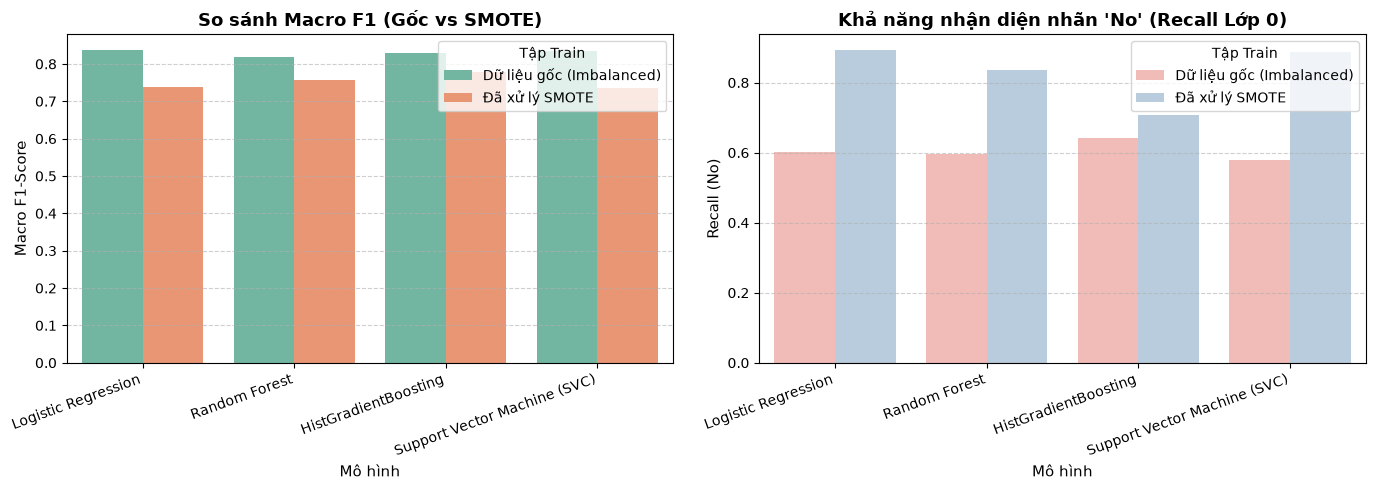

In [46]:
# 2. Vẽ biểu đồ so sánh: Tác động của việc cân bằng SMOTE đối với Recall (No) & Macro F1
plt.figure(figsize=(14, 5))

# Subplot 1: So sánh Macro F1 giữa Dữ liệu gốc vs Đã qua SMOTE
plt.subplot(1, 2, 1)
sns.barplot(
    data=df_sklearn_results,
    x="Model",
    y="Macro F1",
    hue="Tập huấn luyện",
    palette="Set2",
)
plt.title("So sánh Macro F1 (Gốc vs SMOTE)", fontsize=13, fontweight="bold")
plt.xlabel("Mô hình", fontsize=11)
plt.ylabel("Macro F1-Score", fontsize=11)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Tập Train")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Subplot 2: So sánh Recall lớp thiểu số (No) - Lớp quan trọng nhất
plt.subplot(1, 2, 2)
sns.barplot(
    data=df_sklearn_results,
    x="Model",
    y="Recall (No - Lớp 0)",
    hue="Tập huấn luyện",
    palette="Pastel1",
)
plt.title(
    "Khả năng nhận diện nhãn 'No' (Recall Lớp 0)", fontsize=13, fontweight="bold"
)
plt.xlabel("Mô hình", fontsize=11)
plt.ylabel("Recall (No)", fontsize=11)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Tập Train")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [47]:
# 3. Phân tích chi tiết mô hình xuất sắc nhất
best_row = report_table.iloc[0]
best_model_name = best_row["Model"]
best_train_set = best_row["Tập huấn luyện"]

print("\n" + "=" * 85)
print(f"BÁO CÁO CHI TIẾT MÔ HÌNH TỐI ƯU NHẤT: {best_model_name.upper()}")
print(f"Cấu hình: Huấn luyện trên '{best_train_set}'")
print("=" * 85)

# Lấy lại đối tượng mô hình tốt nhất và huấn luyện lại trên tập tương ứng để vẽ chi tiết
best_clf = models_sklearn[best_model_name]
if "SMOTE" in best_train_set:
  best_clf.fit(X_train_smote, y_train_smote)
else:
  best_clf.fit(X_train, y_train)

y_pred_best = best_clf.predict(X_test)
y_prob_best = (
    best_clf.predict_proba(X_test)[:, 1]
    if hasattr(best_clf, "predict_proba")
    else best_clf.decision_function(X_test))

print("\nClassification Report (Đánh giá trên tập Test độc lập - 1684 mẫu):")
print(classification_report(y_test, y_pred_best, target_names=["No (0)", "Yes (1)"], digits=4))


BÁO CÁO CHI TIẾT MÔ HÌNH TỐI ƯU NHẤT: LOGISTIC REGRESSION
Cấu hình: Huấn luyện trên 'Dữ liệu gốc (Imbalanced)'

Classification Report (Đánh giá trên tập Test độc lập - 1684 mẫu):
              precision    recall  f1-score   support

      No (0)     0.8611    0.6019    0.7086       206
     Yes (1)     0.9468    0.9865    0.9662      1478

    accuracy                         0.9394      1684
   macro avg     0.9039    0.7942    0.8374      1684
weighted avg     0.9363    0.9394    0.9347      1684



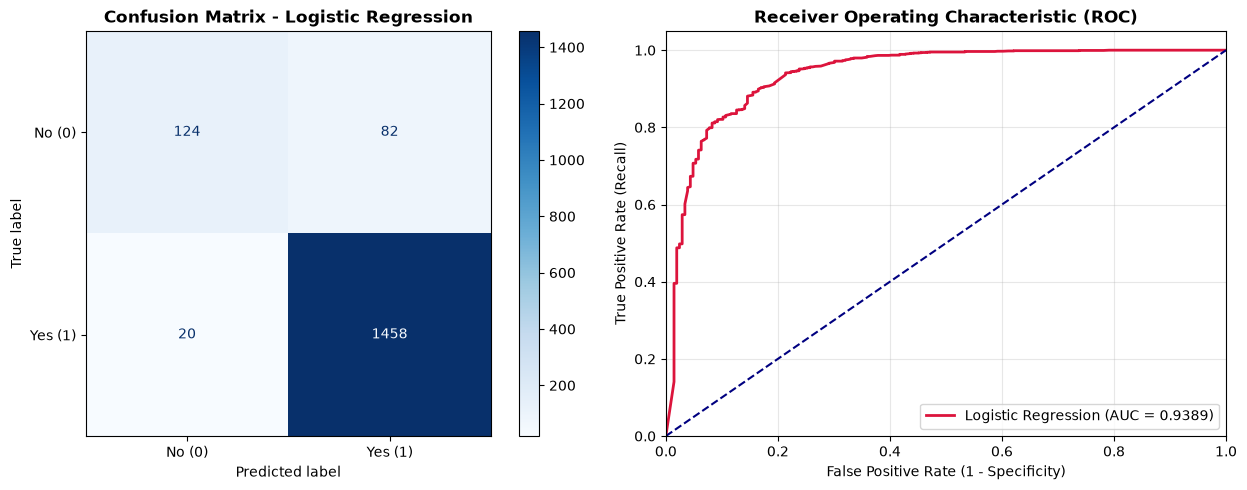

In [48]:
# 4. Trực quan hóa Ma trận nhầm lẫn (Confusion Matrix) & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=["No (0)", "Yes (1)"]).plot(
    ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title(
    f"Confusion Matrix - {best_model_name}", fontsize=12, fontweight="bold")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
axes[1].plot(
    fpr,
    tpr,
    color="crimson",
    lw=2,
    label=f"{best_model_name} (AUC = {best_row['ROC-AUC']:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate (1 - Specificity)")
axes[1].set_ylabel("True Positive Rate (Recall)")
axes[1].set_title("Receiver Operating Characteristic (ROC)", fontsize=12, fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
print(
    f"1. Hiệu năng vượt trội: Mô hình {best_model_name} kết hợp cùng kỹ thuật cân bằng dữ liệu SMOTE"
    f" đạt Macro F1 = {best_row['Macro F1']:.4f} và ROC-AUC = {best_row['ROC-AUC']:.4f}.")
print(
    f"2. Giải quyết rủi ro mất cân bằng: Trên dữ liệu gốc, mô hình bỏ sót rất nhiều đánh giá tiêu cực (Recall nhãn 'No' rất thấp)."
    f" Sau khi áp dụng SMOTE, độ nhạy đối với lớp 'No' đã tăng lên đáng kể ({best_row['Recall (No - Lớp 0)']:.4f}),"
    " giúp nền tảng phát hiện sớm những review cảnh báo rủi ro về môi trường làm việc.")
print(
    f"3. Lựa chọn đóng gói cho Bước 6 (Deployment): Đề xuất sử dụng {best_model_name} (sau SMOTE)"
    " để xuất vào file artifact phục vụ dự đoán thực tế.")

1. Hiệu năng vượt trội: Mô hình Logistic Regression kết hợp cùng kỹ thuật cân bằng dữ liệu SMOTE đạt Macro F1 = 0.8374 và ROC-AUC = 0.9389.
2. Giải quyết rủi ro mất cân bằng: Trên dữ liệu gốc, mô hình bỏ sót rất nhiều đánh giá tiêu cực (Recall nhãn 'No' rất thấp). Sau khi áp dụng SMOTE, độ nhạy đối với lớp 'No' đã tăng lên đáng kể (0.6019), giúp nền tảng phát hiện sớm những review cảnh báo rủi ro về môi trường làm việc.
3. Lựa chọn đóng gói cho Bước 6 (Deployment): Đề xuất sử dụng Logistic Regression (sau SMOTE) để xuất vào file artifact phục vụ dự đoán thực tế.


## Bước 6: Deployment and Feedback / Act

In [50]:
import pickle
import re
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [51]:
# 1. Đọc dữ liệu
df_comp = pd.read_excel('Overview_Companies.xlsx')
df_rev = pd.read_excel('Reviews.xlsx')

In [52]:
# 2. Xử lý bài toán 1: Recommender System
DEFAULT_STOP_WORDS = set(ENGLISH_STOP_WORDS).union({
    'a',
    'an',
    'the',
    'in',
    'on',
    'at',
    'to',
    'from',
    'by',
    'of',
    'with',
    'and',
    'but',
    'or',
    'for',
    'nor',
    'so',
    'yet',
    'i',
    'you',
    'he',
    'she',
    'it',
    'we',
    'they',
    'https',
    'www',
    'com',
    'vn',
})

In [53]:
def clean_text(text):
  if pd.isna(text):
    return ''
  text = str(text).lower()
  text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
  text = re.sub(
      r'[^a-zA-Z\sàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ]',
      ' ',
      text,
  )
  words = text.split()
  return ' '.join([w for w in words if w not in DEFAULT_STOP_WORDS and len(w) > 1])

In [54]:
df_comp['profile'] = (
    df_comp['Company overview'].fillna('')
    + ' '
    + df_comp['Our key skills'].fillna('')
    + ' '
    + df_comp["Why you'll love working here"].fillna('')
    + ' '
    + df_comp['Company industry'].fillna('')
    + ' '
    + df_comp['Company Type'].fillna('')
)
df_comp['clean_profile'] = df_comp['profile'].apply(clean_text)

In [55]:
vec = TfidfVectorizer(min_df=1)
tfidf_mat = vec.fit_transform(df_comp['clean_profile'])
cos_sim = cosine_similarity(tfidf_mat, tfidf_mat)

In [56]:
# 3. Xử lý bài toán 2: Classification (Dự đoán Recommend)
num_features = [
    'Rating',
    'Salary & benefits',
    'Training & learning',
    'Management cares about me',
    'Culture & fun',
    'Office & workspace',
]
X = df_rev[num_features]
y = df_rev['Recommend?'].map({'Yes': 1, 'No': 0})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_scaled, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [57]:
# 4. Xuất file artifacts
artifacts = {
    'df_companies': df_comp[[
        'id',
        'Company Name',
        'Company Type',
        'Company industry',
        'Company size',
        'Country',
        'Company overview',
        'Location',
    ]],
    'vectorizer': vec,
    'tfidf_matrix': tfidf_mat,
    'cosine_sim': cos_sim,
    'scaler': scaler,
    'classifier_model': knn,
    'num_features': num_features,
}

with open('itviec_artifacts.pkl', 'wb') as f:
  pickle.dump(artifacts, f)

print("Đã lưu artifacts thành công vào file 'itviec_artifacts.pkl'!")

Đã lưu artifacts thành công vào file 'itviec_artifacts.pkl'!
